# Percentile thresholding & aggregated SDM outputs (prototype)

Notebook-focused workflow: continuous **0–1** suitability → **binary threshold layers** → **potential** species-count surfaces. Each run **overwrites** **`aggregate_*`** COGs (**nine**) and **`threshold_binary_*`** COGs (**3 × matched prediction bands**), all **EPSG:3857**; aggregates are **`float32`** with **`NaN`** where stacks are incomplete — binaries are **`uint8`** (**0**/ **1**/ **255** nodata); plus **`aggregate_qa_latest.csv`**. Maps stay in-session unless you export manually.

**Not** observed richness or confirmed presence.

Helper functions are defined here so they can move into modules later.


## 1. Setup and configuration

Paths and threshold labels are in the next code cell. **Latest artefacts** under **`data/sdm_predictions/`** (overwrite each run): **`aggregate_<scenario>_{all|roost|in_flight}_latest.tif`** (**nine** count COGs, `float32`); **`threshold_binary_<scenario>_<band_key>_latest.tif`** (**3 × band count**, `uint8`); **`aggregate_qa_latest.csv`** after §7. `band_key` = `get_model_id([latin_name, activity_type])` (§2).

`PLOT_STEP` subsamples the prediction raster for maps, binary stacks, and exports. **Exported** `aggregate_*` and `threshold_binary_*` **COGs** are **EPSG:3857** via `rio-cogeo`; notebook maps use the native grid/CRS of `all_predictions.tif`.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import xarray as xr
from IPython.display import display
from affine import Affine
from rasterio import transform as rio_transform
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
from rasterio.warp import calculate_default_transform, reproject
from rasterio.windows import Window
from rio_cogeo.cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles

from sdm.utils.io import load_pickled_model, set_project_wd
from sdm.commands.modelling.utils import get_model_id
from sdm.models.core.pipeline_features import pipeline_selected_feature_names

set_project_wd(verbose=False)

REPO_ROOT = Path.cwd()
PATH_MODEL_RESULTS = REPO_ROOT / "data" / "sdm_models" / "model_results.csv"
PATH_TRAINING = REPO_ROOT / "data" / "sdm_models" / "training_data.parquet"
PATH_PREDICTIONS = REPO_ROOT / "data" / "sdm_predictions" / "all_predictions.tif"
DIR_PREDICTIONS = PATH_PREDICTIONS.parent
# Exports (§6): aggregate + per-band binary COGs and QA CSV under predictions; fixed names, overwrite each run.
PATH_AGGREGATE_QA_LATEST = DIR_PREDICTIONS / "aggregate_qa_latest.csv"

# GeoTIFF export CRS (notebook maps/analysis stay in native CRS of all_predictions.tif).
AGGREGATE_EXPORT_EPSG = 3857

# Subsample native prediction grid (`height // PLOT_STEP`, average resampling). Use 1 for full resolution.
PLOT_STEP = 4

THRESHOLD_COLS = {
    "p00_min_presence": "threshold_p00_min_presence",
    "p10_main": "threshold_p10_main",
    "p25_conservative": "threshold_p25_conservative",
}

plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})


## 2. Load and inspect source artefacts


In [2]:
def load_model_results(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Missing model index: {path}")
    df = pd.read_csv(path)
    df["band_key"] = df.apply(
        lambda r: get_model_id([r["latin_name"], r["activity_type"]]), axis=1
    )
    return df


def load_training_data(path: Path) -> pd.DataFrame | gpd.GeoDataFrame:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing training parquet: {path}. Run `sdm train` (writes training_data.parquet)."
        )
    try:
        return gpd.read_parquet(path)
    except Exception:
        return pd.read_parquet(path)


def inspect_prediction_raster(path: Path) -> dict:
    if not path.is_file():
        raise FileNotFoundError(
            f"Missing prediction raster: {path}. Run `sdm predict` (writes all_predictions.tif)."
        )
    with rio.open(path) as src:
        return {
            "path": path,
            "count": src.count,
            "crs": src.crs,
            "transform": src.transform,
            "bounds": src.bounds,
            "shape": (src.height, src.width),
            "nodata": src.nodata,
            "descriptions": list(src.descriptions) if src.descriptions else [],
            "dtypes": list(src.dtypes),
        }


model_results = load_model_results(PATH_MODEL_RESULTS)
training_df = load_training_data(PATH_TRAINING)
pred_info = inspect_prediction_raster(PATH_PREDICTIONS)

display(model_results.head())
print("Training columns:", list(training_df.columns))
print("Training rows:", len(training_df))
if "class" in training_df.columns:
    print(
        "Presence:",
        int((training_df["class"] == 1).sum()),
        "Background:",
        int((training_df["class"] == 0).sum()),
    )
if "identifier" in training_df.columns:
    print("Unique training identifiers:", training_df["identifier"].nunique())
print(
    "Raster shape:",
    pred_info["shape"],
    "bands:",
    pred_info["count"],
    "nodata:",
    pred_info["nodata"],
)
print("CRS:", pred_info["crs"])
print("Band descriptions:", pred_info["descriptions"])


,identifier,latin_name,activity_type,mean_cv_score,std_cv_score,n_presence,n_background,model_path,band_key
0,Nyctalus noctula_In flight,Nyctalus noctula,In flight,0.834915,0.070300,312,2346,data/sdm_models/Nyctalus noctula_In flight.pkl,nyctalus_noctula_in_flight
1,Nyctalus noctula_Roost,Nyctalus noctula,Roost,0.811137,0.045454,74,740,data/sdm_models/Nyctalus noctula_Roost.pkl,nyctalus_noctula_roost
2,Pipistrellus pipistrellus_In flight,Pipistrellus pipistrellus,In flight,0.838518,0.067742,630,2306,data/sdm_models/Pipistrellus pipistrellus_In f...,pipistrellus_pipistrellus_in_flight
3,Pipistrellus pipistrellus_Roost,Pipistrellus pipistrellus,Roost,0.889527,0.052900,1215,2214,data/sdm_models/Pipistrellus pipistrellus_Roos...,pipistrellus_pipistrellus_roost
4,Pipistrellus pygmaeus_In flight,Pipistrellus pygmaeus,In flight,0.813043,0.108205,265,2346,data/sdm_models/Pipistrellus pygmaeus_In fligh...,pipistrellus_pygmaeus_in_flight


Training columns: ['class', 'sample_weight', 'geometry', 'climate_stats_temp_ann_var', 'climate_bioclim_bio_4', 'climate_bioclim_bio_7', 'climate_bioclim_bio_2', 'climate_stats_prec_ann_var', 'terrain_dtm', 'climate_stats_prec_ann_avg', 'climate_stats_temp_ann_avg', 'climate_stats_temp_mat_avg', 'ceh_landcover_wetland', 'os_distance_distance_to_buildings', 'os_distance_distance_to_minor_roads', 'climate_bioclim_bio_9', 'bgs_coast_distance_to_coast', 'ceh_landcover_upland_heathland', 'terrain_stats_roughness', 'ceh_landcover_grassland', 'climate_bioclim_bio_8', 'os_distance_distance_to_major_roads', 'ceh_landcover_arable', 'terrain_stats_slope', 'climate_stats_wind_ann_avg', 'climate_bioclim_bio_3', 'vom_vegetation_height_max', 'vom_vegetation_height_std', 'ceh_landcover_broadleaved_woodland', 'vom_vegetation_height_mean', 'ceh_landcover_suburban', 'os_cover_buildings', 'terrain_stats_tpi', 'os_cover_water', 'terrain_stats_twi', 'ceh_landcover_coniferous_woodland', 'ceh_landcover_urban'

### Identifier alignment

- `identifier` in CSV and training (e.g. `Nyctalus noctula_In flight`)
- `band_key` = `get_model_id([latin_name, activity_type])` matches **raster band descriptions** from `sdm predict` (`nyctalus_noctula_in_flight`)


In [3]:
model_ids_from_results = set(model_results["identifier"])
model_ids_from_training = (
    set(training_df["identifier"].unique())
    if "identifier" in training_df.columns
    else set()
)
model_ids_from_raster_bands = {d for d in pred_info["descriptions"] if d}
band_keys_from_results = set(model_results["band_key"])

in_results_and_training = model_ids_from_results & model_ids_from_training
band_keys_matched = sorted(band_keys_from_results & model_ids_from_raster_bands)

mr_use = (
    model_results[
        model_results["identifier"].isin(in_results_and_training)
        & model_results["band_key"].isin(band_keys_matched)
    ]
    .copy()
    .sort_values(["activity_type", "latin_name"])
    .reset_index(drop=True)
)

print(
    "Identifiers in both CSV and training:",
    len(in_results_and_training),
    "| band_key also in raster:",
    len(band_keys_matched),
)
print(
    "CSV ids missing from training:", model_ids_from_results - model_ids_from_training
)
print(
    "CSV band_key missing from raster:",
    sorted(band_keys_from_results - model_ids_from_raster_bands),
)
print(
    "Training ids missing from CSV:", model_ids_from_training - model_ids_from_results
)

if not band_keys_matched:
    raise RuntimeError("No raster bands match model_results; stopping.")

if mr_use.duplicated(subset=["band_key"], keep=False).any():
    _d = mr_use.loc[mr_use.duplicated(subset=["band_key"], keep=False)].sort_values(
        "band_key"
    )
    print(
        "\n*** WARNING: duplicate band_key rows in intersected model_results;",
        "`band_axes` keeps the first row per band_key:",
        _d[["band_key", "identifier", "latin_name"]].to_string(index=False),
        "***\n",
        sep="\n",
    )

if (band_keys_from_results - model_ids_from_raster_bands) or (
    model_ids_from_results - model_ids_from_training
):
    print(
        "\n*** WARNING: using intersection only; fix data or regenerate predictions. ***\n"
    )

raster_band_keys_ordered = [
    d for d in pred_info["descriptions"] if d in band_keys_matched
]
print("Matched models (raster band order):", len(raster_band_keys_ordered))
mr_by_band = mr_use.set_index("band_key")

for d in raster_band_keys_ordered:
    if d not in mr_by_band.index:
        raise KeyError(
            f"Raster band description {d!r} has no row in model_results / training intersection"
        )

band_axes = (
    mr_use.drop_duplicates(subset=["band_key"], keep="first")
    .set_index("band_key")
    .loc[raster_band_keys_ordered][["identifier", "latin_name", "activity_type"]]
    .assign(band_ix=np.arange(len(raster_band_keys_ordered)))
)
display(band_axes)


Identifiers in both CSV and training: 17 | band_key also in raster: 17
CSV ids missing from training: set()
CSV band_key missing from raster: []
Training ids missing from CSV: set()
Matched models (raster band order): 17


,identifier,latin_name,activity_type,band_ix
band_key,,,,
nyctalus_noctula_in_flight,Nyctalus noctula_In flight,Nyctalus noctula,In flight,0
nyctalus_noctula_roost,Nyctalus noctula_Roost,Nyctalus noctula,Roost,1
pipistrellus_pipistrellus_in_flight,Pipistrellus pipistrellus_In flight,Pipistrellus pipistrellus,In flight,2
pipistrellus_pipistrellus_roost,Pipistrellus pipistrellus_Roost,Pipistrellus pipistrellus,Roost,3
pipistrellus_pygmaeus_in_flight,Pipistrellus pygmaeus_In flight,Pipistrellus pygmaeus,In flight,4
pipistrellus_pygmaeus_roost,Pipistrellus pygmaeus_Roost,Pipistrellus pygmaeus,Roost,5
myotis_daubentonii_in_flight,Myotis daubentonii_In flight,Myotis daubentonii,In flight,6
myotis_daubentonii_roost,Myotis daubentonii_Roost,Myotis daubentonii,Roost,7
plecotus_auritus_in_flight,Plecotus auritus_In flight,Plecotus auritus,In flight,8


### Notebook utilities (`xarray`, vectorised masking)

Everything below stays local to this notebook; short functions keep section cells declarative.

In [4]:
def continuous_valid_mask(cube_nb_hw: np.ndarray, nodata: float | None) -> np.ndarray:
    """Finite pixels; exclude equality to a **finite** nodata sentinel only."""
    ok = np.isfinite(cube_nb_hw)
    if nodata is None:
        return ok
    nod = np.asarray(nodata)
    if nod.size == 0:
        return ok
    # NumPy: `cube != np.nan` is True for every element — never compare to NaN as nodata here.
    if nod.size == 1 and not np.isfinite(nod.reshape(-1)[0].astype(np.float64, copy=False)):
        return ok
    ok &= cube_nb_hw != nod
    return ok


def predictions_subsampled_array(
    raster_path: Path,
    band_keys_ordered: list[str],
    descriptions: list[str],
    plot_step: int,
) -> xr.DataArray:
    idxs = [descriptions.index(bk) + 1 for bk in band_keys_ordered]
    with rio.open(raster_path) as src:
        nodata = src.nodata
        hs, ws = max(1, src.height // plot_step), max(1, src.width // plot_step)
        stacked = np.stack(
            [
                src.read(ix, out_shape=(hs, ws), resampling=Resampling.average).astype(
                    np.float64
                )
                for ix in idxs
            ],
            axis=0,
        )
    return xr.DataArray(
        stacked,
        dims=("band_key", "y", "x"),
        coords={"band_key": band_keys_ordered},
        name="prediction",
        attrs={"nodata": nodata},
    )


def binary_stacks_vectorised(
    cont: xr.DataArray,
    band_keys_ordered: list[str],
    thresh_table: pd.DataFrame,
    threshold_cols_map: dict[str, str],
    bin_nodata: int,
) -> dict[str, xr.DataArray]:
    th_aligned = thresh_table.set_index("band_key").reindex(band_keys_ordered)
    cube = cont.values.astype(np.float64)
    nod = cont.attrs["nodata"]
    valid_hw = continuous_valid_mask(cube, nod)
    out: dict[str, xr.DataArray] = {}
    for label, col in threshold_cols_map.items():
        tvec = (
            pd.to_numeric(th_aligned[col], errors="coerce")
            .to_numpy(dtype=np.float64)
            .reshape(-1, 1, 1)
        )
        miss_b = np.isnan(tvec)
        hi = np.full(cube.shape, bin_nodata, dtype=np.uint8)
        ok = (~miss_b) & valid_hw
        t_b = np.broadcast_to(tvec, cube.shape)
        hi[ok] = (cube[ok] >= t_b[ok]).astype(np.uint8)
        out[label] = xr.DataArray(
            hi, coords=cont.coords, dims=cont.dims, attrs={"scenario": label}
        )
    return out


def aggregate_species_layers(
    binary_cube_nb_hw: np.ndarray,
    band_axes_tbl: pd.DataFrame,
    prediction_valid_nb_hw: np.ndarray,
) -> dict[str, np.ndarray]:
    """Potential species-count maps (float).

    Requires every prediction band to have usable continuous suitability at each pixel.
    If any band is nodata/non-finite (see ``prediction_valid_nb_hw``), counts are nan so we
    do not implicitly treat gaps as definite absences. Aggregation counts only cells where the
    binary stack equals 1 (see ``binary_stacks_vectorised``).

    Values are suitability-based indices, not field richness.
    """
    ro = band_axes_tbl.activity_type.eq("Roost").to_numpy()
    fl = band_axes_tbl.activity_type.eq("In flight").to_numpy()
    cube = binary_cube_nb_hw.astype(np.uint8, copy=False)
    pred_ok = prediction_valid_nb_hw.astype(bool, copy=False)
    all_known = pred_ok.all(axis=0)

    if ro.any():
        rs_plain = np.sum(cube[ro] == 1, axis=0).astype(np.float64)
        rs = np.where(all_known, rs_plain, np.nan)
    else:
        rs = np.zeros(all_known.shape, dtype=np.float64)

    if fl.any():
        fc_plain = np.sum(cube[fl] == 1, axis=0).astype(np.float64)
        fc = np.where(all_known, fc_plain, np.nan)
    else:
        fc = np.zeros(all_known.shape, dtype=np.float64)

    tot_plain = np.zeros(all_known.shape, dtype=np.float64)
    for _, g in band_axes_tbl.groupby("latin_name", sort=False):
        sub = cube[g["band_ix"].to_numpy()]
        tot_plain += np.any(sub == 1, axis=0).astype(np.float64)
    tot = np.where(all_known, tot_plain, np.nan)

    return {"all": tot, "roost": rs, "in_flight": fc}


def map_flip_ud_for_imshow(transform: object) -> bool:
    """True when rows from Rasterio reads need a vertical flip for north-at-top imshow."""

    try:
        e = float(getattr(transform, "e"))
    except (TypeError, ValueError):
        return False
    # Positive ∂y/∂row: row 0 is at smaller projected northing/easting-y → south at image top unless flipped.
    return e > 0


def orient_raster_plane_for_maps(
    arr: np.ndarray, *, transform: object
) -> np.ndarray | np.ma.MaskedArray:
    plane = np.asanyarray(arr)
    if plane.ndim != 2:
        return plane
    if map_flip_ud_for_imshow(transform):
        # Use np.flipud (not numpy.ma.flipud—the ma submodule never had it). np.flipud
        # preserves MaskedArray subclasses and masks.
        return np.flipud(plane)
    return plane


def add_subsampled_pixel_qa(
    qa: pd.DataFrame,
    binaries: dict[str, np.ndarray],
    band_keys_ordered: list[str],
    bin_nodata: int,
) -> pd.DataFrame:
    key_to_ix = {bk: i for i, bk in enumerate(band_keys_ordered)}
    for tlab, cube in binaries.items():
        sel = qa["threshold_label"].eq(tlab)
        for ix in qa.index[sel]:
            bk = qa.at[ix, "band_key"]
            band = cube[key_to_ix[bk]].ravel()
            valid = band != bin_nodata
            suited = valid & (band == 1)
            qa.at[ix, "suitable_cell_count"] = int(suited.sum())
            qa.at[ix, "valid_cell_count"] = int(valid.sum())
            v = valid.sum()
            qa.at[ix, "suitable_area_percent"] = (
                100.0 * suited.sum() / float(v) if v else np.nan
            )
    return qa


def merge_secondary_qa_warnings(qa: pd.DataFrame) -> pd.DataFrame:
    extra = []
    for _, row in qa.iterrows():
        p = []
        if row["threshold_label"] == "p10_main":
            eo = row["training_omission_rate"]
            if pd.notna(eo) and abs(float(eo) - 0.10) > 0.08:
                p.append("omission_not_near_10pct")
            sp = row["suitable_area_percent"]
            if pd.notna(sp):
                if float(sp) > 80:
                    p.append("suitable_pct>80")
                if float(sp) < 1:
                    p.append("suitable_pct<1")
        extra.append("; ".join(p))
    add = ["; " + e if e else "" for e in extra]
    out = qa.copy()
    out["warning"] = out["warning"].fillna("") + add
    return out


def modeling_quality_warnings(n_presence: int, mean_cv) -> list[str]:
    w = []
    if n_presence < 30:
        w.append("n_presence<30")
    if pd.isna(mean_cv):
        w.append("mean_cv_missing")
    elif float(mean_cv) < 0.7:
        w.append("mean_cv<0.7")
    return w


def presence_suitability_scores(model_path: str | Path, sub_pr) -> np.ndarray | None:
    model = load_pickled_model(model_path)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            X = sub_pr.drop(columns=["geometry"], errors="ignore").copy()
            return model.predict_proba(X)[:, 1]
        except Exception:
            fn = pipeline_selected_feature_names(model)
            return model.predict_proba(sub_pr.loc[:, fn])[:, 1]


def summarise_scores(scores: np.ndarray) -> dict[str, float]:
    return {
        "presence_score_min": float(scores.min()),
        "presence_score_p10": float(np.percentile(scores, 10)),
        "presence_score_p25": float(np.percentile(scores, 25)),
        "presence_score_median": float(np.percentile(scores, 50)),
        "presence_score_mean": float(scores.mean()),
        "presence_score_max": float(scores.max()),
        "threshold_p00_min_presence": float(scores.min()),
        "threshold_p10_main": float(np.percentile(scores, 10)),
        "threshold_p25_conservative": float(np.percentile(scores, 25)),
    }


## 3. Presence-based percentile thresholds


In [5]:
# Presence scores → threshold table (keeps ``score_arrays`` for omission QA)
score_arrays: dict[str, np.ndarray] = {}

rows_out = []
for _, row in mr_use.iterrows():
    ident = row["identifier"]
    sub_all = training_df.loc[training_df["identifier"].eq(ident)]
    sub_pr = sub_all.loc[sub_all["class"].eq(1)]
    warn_parts = modeling_quality_warnings(len(sub_pr), row.get("mean_cv_score"))

    scores = None
    try:
        scores = presence_suitability_scores(row["model_path"], sub_pr)
    except Exception as e:
        warn_parts.append(f"predict_fail:{e!r}")
    if scores is None or scores.size == 0:
        warn_parts.append("no_scores")
        stats = {
            k: np.nan
            for k in (
                "presence_score_min",
                "presence_score_p10",
                "presence_score_p25",
                "presence_score_median",
                "presence_score_mean",
                "presence_score_max",
                "threshold_p00_min_presence",
                "threshold_p10_main",
                "threshold_p25_conservative",
            )
        }
    else:
        score_arrays[ident] = scores
        stats = summarise_scores(scores)

    rows_out.append(
        {
            **stats,
            "identifier": ident,
            "band_key": row["band_key"],
            "latin_name": row["latin_name"],
            "activity_type": row["activity_type"],
            "n_presence": len(sub_pr),
            "n_background": int(sub_all["class"].eq(0).sum()),
            "mean_cv_score": row.get("mean_cv_score"),
            "std_cv_score": row.get("std_cv_score"),
            "warning": "; ".join(warn_parts),
        }
    )

threshold_summary = pd.DataFrame(rows_out).sort_values(["activity_type", "latin_name"])
display(threshold_summary)


,presence_score_min,presence_score_p10,presence_score_p25,presence_score_median,presence_score_mean,presence_score_max,threshold_p00_min_presence,threshold_p10_main,threshold_p25_conservative,identifier,band_key,latin_name,activity_type,n_presence,n_background,mean_cv_score,std_cv_score,warning
0,0.015289,0.102357,0.338757,0.712078,0.651478,1.000000,0.015289,0.102357,0.338757,Myotis daubentonii_In flight,myotis_daubentonii_in_flight,Myotis daubentonii,In flight,116,1160,0.883516,0.044050,
1,0.003697,0.193533,0.825876,0.999987,0.799036,1.000000,0.003697,0.193533,0.825876,Myotis mystacinus_In flight,myotis_mystacinus_in_flight,Myotis mystacinus,In flight,32,320,0.769437,0.001274,
2,0.024518,0.075418,0.492460,0.772446,0.645503,0.999464,0.024518,0.075418,0.492460,Myotis nattereri_In flight,myotis_nattereri_in_flight,Myotis nattereri,In flight,43,430,0.784840,0.072586,
3,0.048800,0.286789,0.512611,0.821441,0.707719,1.000000,0.048800,0.286789,0.512611,Nyctalus leisleri_In flight,nyctalus_leisleri_in_flight,Nyctalus leisleri,In flight,82,820,0.776375,0.148796,
4,0.043715,0.211836,0.376387,0.668460,0.632268,1.000000,0.043715,0.211836,0.376387,Nyctalus noctula_In flight,nyctalus_noctula_in_flight,Nyctalus noctula,In flight,312,2377,0.834915,0.070300,
5,0.000076,0.264156,0.485193,0.712637,0.659512,0.999830,0.000076,0.264156,0.485193,Pipistrellus pipistrellus_In flight,pipistrellus_pipistrellus_in_flight,Pipistrellus pipistrellus,In flight,630,2327,0.838518,0.067742,
6,0.008793,0.155125,0.405029,0.695187,0.638517,1.000000,0.008793,0.155125,0.405029,Pipistrellus pygmaeus_In flight,pipistrellus_pygmaeus_in_flight,Pipistrellus pygmaeus,In flight,265,2375,0.813043,0.108205,
7,0.010541,0.191168,0.373747,0.747126,0.649153,1.000000,0.010541,0.191168,0.373747,Plecotus auritus_In flight,plecotus_auritus_in_flight,Plecotus auritus,In flight,141,1410,0.822687,0.087852,
8,0.423023,0.738134,0.995923,1.000000,0.931743,1.000000,0.423023,0.738134,0.995923,Myotis brandtii_Roost,myotis_brandtii_roost,Myotis brandtii,Roost,27,270,0.833472,0.094263,n_presence<30
9,0.003030,0.089460,0.437585,0.842809,0.678192,1.000000,0.003030,0.089460,0.437585,Myotis daubentonii_Roost,myotis_daubentonii_roost,Myotis daubentonii,Roost,124,1240,0.835988,0.022541,


## 4. Presence score distributions


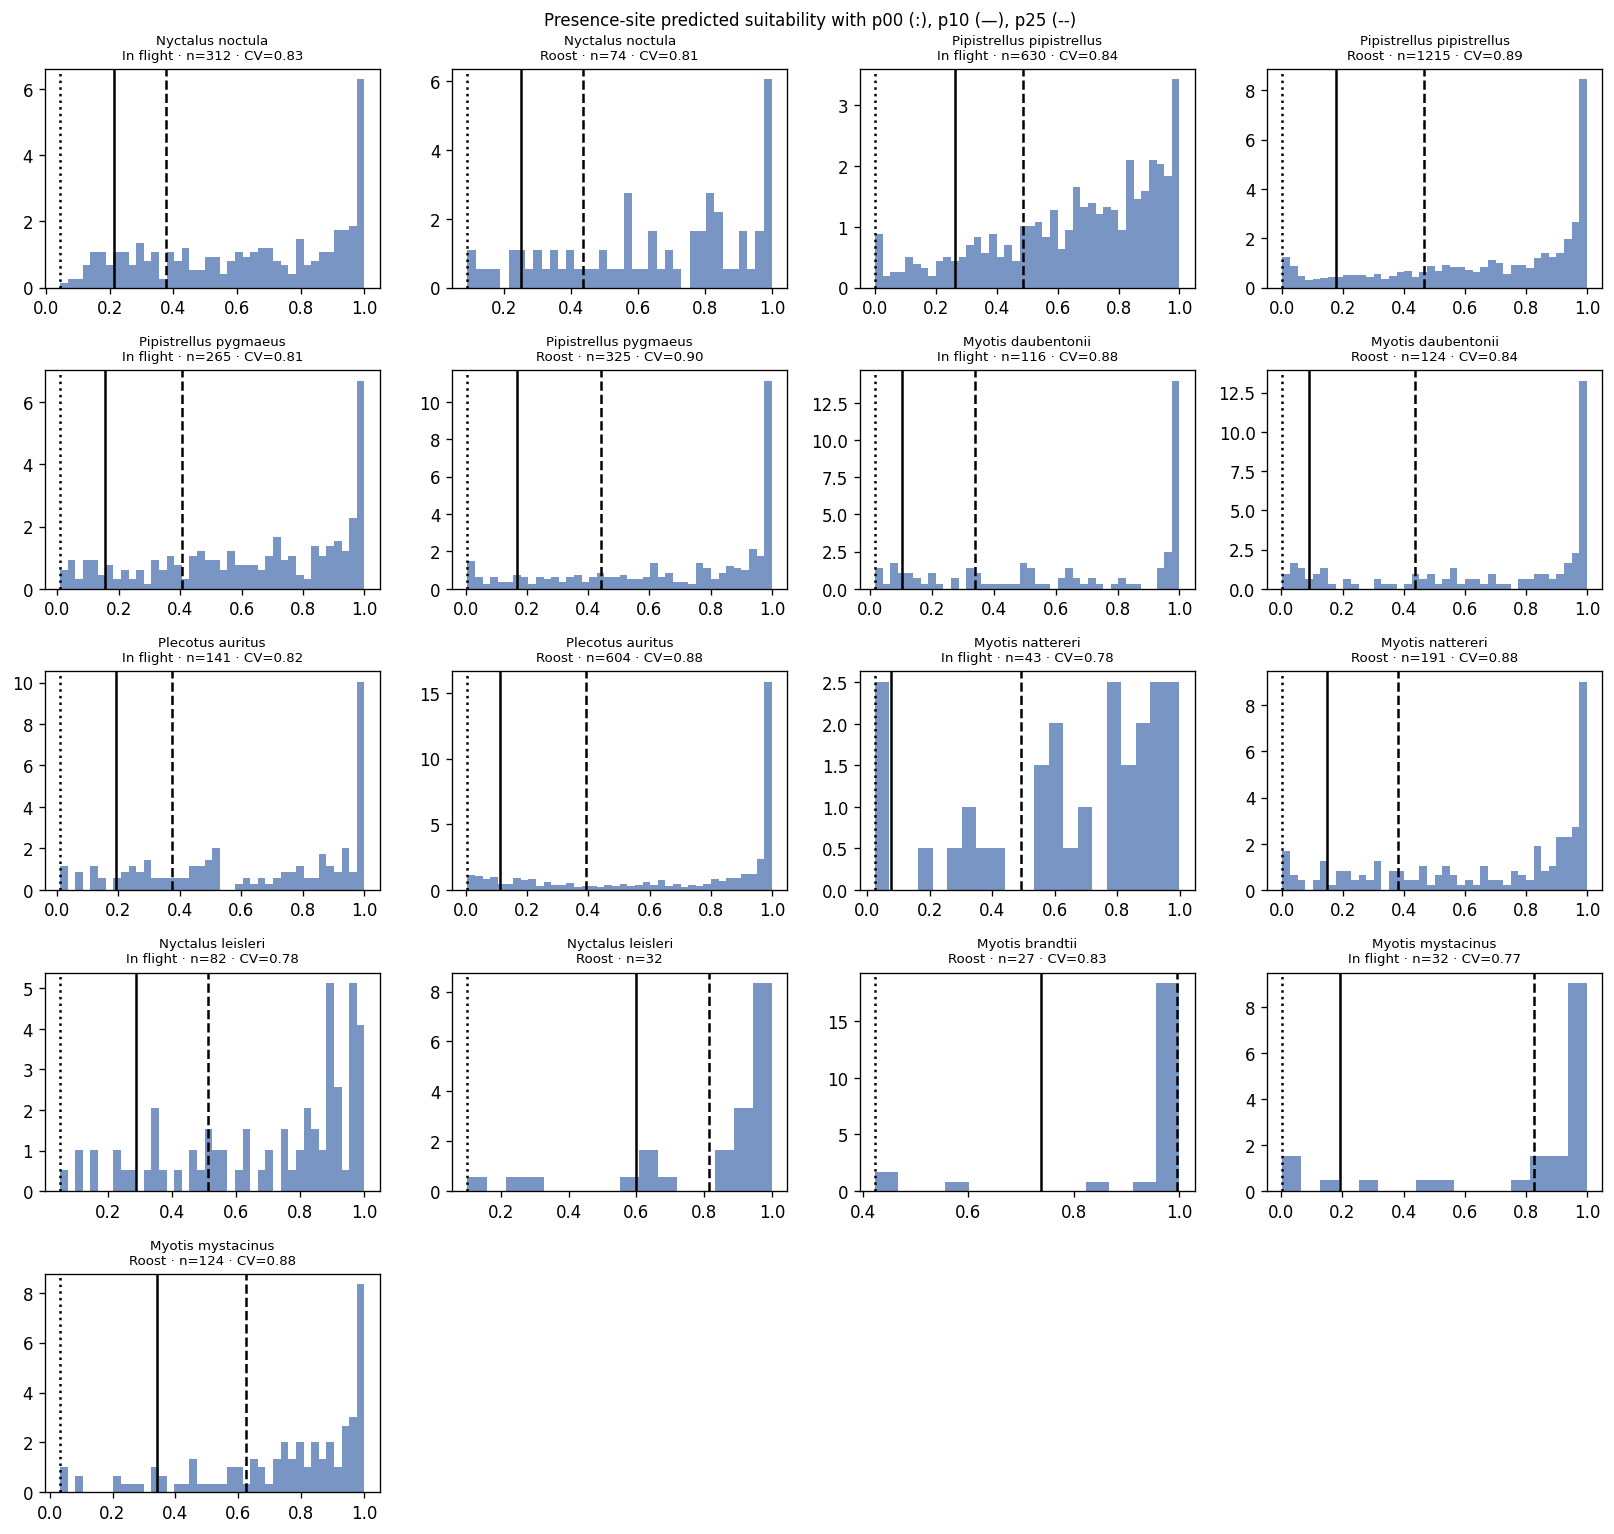

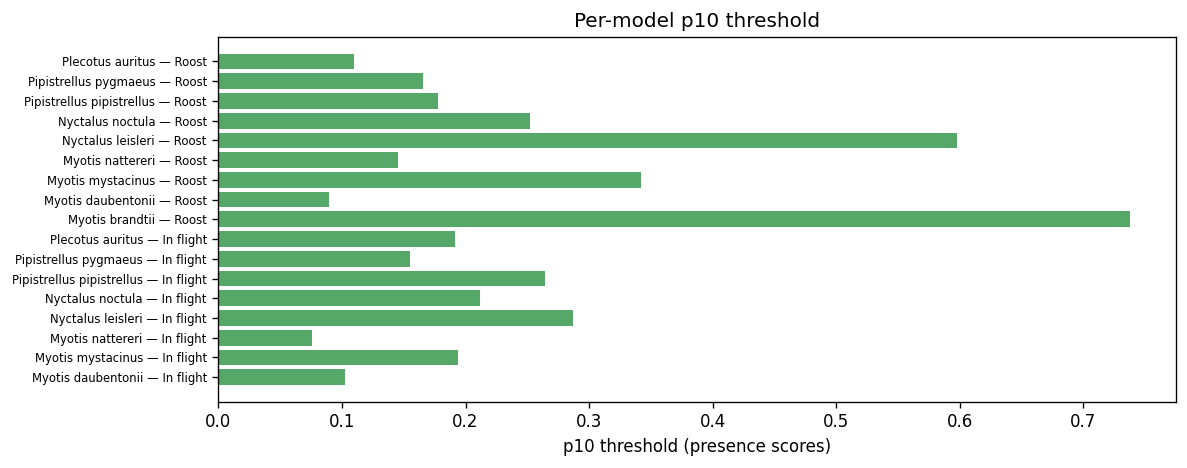

In [6]:
thresh_by_bk = threshold_summary.set_index("band_key")
nplots = len(raster_band_keys_ordered)
ncol = min(4, max(3, int(np.ceil(np.sqrt(nplots)))))
nrow = int(np.ceil(nplots / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.4, nrow * 2.6), squeeze=False)
for ax in axes.flat:
    ax.axis("off")
for i, bk in enumerate(raster_band_keys_ordered):
    ax = axes.flat[i]
    row = thresh_by_bk.loc[bk]
    ident = row["identifier"]
    sc = score_arrays.get(ident)
    ax.set_axis_on()
    if sc is None or sc.size == 0:
        ax.text(0.5, 0.5, "no scores", ha="center")
        continue
    ax.hist(
        sc,
        bins=min(40, max(10, len(sc) // 2)),
        density=True,
        color="#4C72B0",
        alpha=0.75,
    )
    for x, ls in [
        (row["threshold_p00_min_presence"], ":"),
        (row["threshold_p10_main"], "-"),
        (row["threshold_p25_conservative"], "--"),
    ]:
        if pd.notna(x):
            ax.axvline(float(x), color="k", ls=ls, lw=1.5)
    mcv = row["mean_cv_score"]
    ttl = (
        row["latin_name"]
        + chr(10)
        + f"{row['activity_type']} · n={int(row['n_presence'])}"
    )
    if pd.notna(mcv):
        ttl += f" · CV={float(mcv):.2f}"
    ax.set_title(ttl, fontsize=8)
fig.suptitle(
    "Presence-site predicted suitability with p00 (:), p10 (—), p25 (--)", fontsize=10
)
plt.tight_layout()
plt.show()

# Thresholds by species (p10) — one row per model
fig2, ax2 = plt.subplots(figsize=(10, max(4, 0.22 * len(threshold_summary))))
y = np.arange(len(threshold_summary))
ax2.barh(y, threshold_summary["threshold_p10_main"].fillna(0), color="#55A868")
ax2.set_yticks(y)
ax2.set_yticklabels(
    threshold_summary["latin_name"] + " — " + threshold_summary["activity_type"],
    fontsize=7,
)
ax2.set_xlabel("p10 threshold (presence scores)")
ax2.set_title("Per-model p10 threshold")
plt.tight_layout()
plt.show()


## 5. Threshold continuous predictions (in memory, subsampled)

Read matched bands from `all_predictions.tif` at reduced resolution (`PLOT_STEP` via `Resampling.average`), then build binary stacks per threshold scenario.


In [7]:
# If §1 was not re-run, use the same default as setup (`PLOT_STEP = 4`).
if "PLOT_STEP" not in globals():
    PLOT_STEP = 4
else:
    PLOT_STEP = int(PLOT_STEP)

th_lookup = threshold_summary.set_index("band_key")
BIN_NODATA = 255

pred_continuous = predictions_subsampled_array(
    PATH_PREDICTIONS, raster_band_keys_ordered, pred_info["descriptions"], PLOT_STEP
)
EXPLORE_GRID_SHAPE = (int(pred_continuous.sizes["y"]), int(pred_continuous.sizes["x"]))

_binary_xr = binary_stacks_vectorised(
    pred_continuous,
    raster_band_keys_ordered,
    threshold_summary,
    THRESHOLD_COLS,
    BIN_NODATA,
)
binary_explore = {k: da.values for k, da in _binary_xr.items()}

_prediction_valid_nb_hw = continuous_valid_mask(
    pred_continuous.values.astype(np.float64),
    pred_continuous.attrs.get("nodata"),
)

pred_continuous.shape, {k: v.shape for k, v in binary_explore.items()}


((17, 392, 490),
 {'p00_min_presence': (17, 392, 490),
  'p10_main': (17, 392, 490),
  'p25_conservative': (17, 392, 490)})

## 6. Aggregates & exports (counts + binary threshold COGs)

Layers in **`aggregate_explore`** plus **thresholded binaries** (`binary_explore`): §6 writes **nine** **`aggregate_<scenario>_<slice>_latest.tif`** (species-count COGs, `float32`, `NaN` when incomplete stack) **and** **`threshold_binary_<scenario>_<band_key>_latest.tif`** for each fitted band × scenario (`uint8`: 0 unsuitable, 1 suitable, 255 missing), **Web Mercator COGs**, **overwrite** each run.

Each species–activity layer is **binary** after thresholding before aggregation. Stored counts are **`float`** maps: **`NaN`** wherever **any** matched prediction band had non-finite or nodata continuous suitability (`continuous_valid_mask`), so gaps are never read as definitive zero-richness inside the stacked models. Elsewhere counts are integers 0 … N (suitability index, not field richness). With a single-band stack, plausible counts elsewhere cap at **0 or 1**.


In [8]:
aggregate_explore = {
    lab: aggregate_species_layers(
        binary_explore[lab],
        band_axes,
        _prediction_valid_nb_hw,
    )
    for lab in THRESHOLD_COLS
}
sorted(aggregate_explore.keys())

_n_expected = len(raster_band_keys_ordered)
_ref = aggregate_explore["p10_main"]


def _masked_valid(u: np.ndarray) -> np.ndarray:
    flat = np.ravel(np.asarray(u, dtype=np.float64))
    return flat[np.isfinite(flat)]


_max_obs_all = 0
for _slice_name in ("all", "roost", "in_flight"):
    v = _masked_valid(_ref[_slice_name]).astype(np.int64)
    _mx = int(v.max(initial=0)) if v.size else 0
    if _slice_name == "all":
        _max_obs_all = _mx
    print(
        f"Aggregate {_slice_name!r}: finite max {_mx}; "
        f"max possible given matched bands ({_n_expected})."
    )
if _n_expected <= 1:
    print(
        "Note: only one matched prediction band → combined counts cap at 0 or 1. "
        "Stack more models into all_predictions.tif to raise that ceiling."
    )
elif _max_obs_all <= 1:
    print(
        "Note: with several bands but max combined count ≤1 everywhere on this grid, "
        "maps stay two-toned until more species co-occur as suitable."
    )
# COG exports (rio-cogeo, EPSG:3857): species-count rasters below; then threshold_binary_* UINT8 COGs.
_h, _w = EXPLORE_GRID_SHAPE
_src_tf = pred_info["transform"] * Affine.scale(float(PLOT_STEP), float(PLOT_STEP))
_src_crs = pred_info["crs"]
_dst_crs = CRS.from_epsg(AGGREGATE_EXPORT_EPSG)
_left, _bottom, _right, _top = rio_transform.array_bounds(_h, _w, _src_tf)
_dst_tf3857, _w3857, _h3857 = calculate_default_transform(
    _src_crs, _dst_crs, _w, _h, _left, _bottom, _right, _top
)
_agg_mem_profile = {
    "driver": "GTiff",
    "width": int(_w3857),
    "height": int(_h3857),
    "count": 1,
    "dtype": "float32",
    "crs": _dst_crs,
    "transform": _dst_tf3857,
}
_cog_kw = cog_profiles.get("deflate").copy()
_cog_kw.update(dtype="float32", predictor=3)
_aggregate_written_paths: list[str] = []
for _tlab in THRESHOLD_COLS:
    for _slice in ("all", "roost", "in_flight"):
        _path = DIR_PREDICTIONS / f"aggregate_{_tlab}_{_slice}_latest.tif"
        _plane = np.ascontiguousarray(
            aggregate_explore[_tlab][_slice].astype(np.float32)
        )
        _dst_plane = np.full((_h3857, _w3857), np.nan, dtype=np.float32)
        reproject(
            source=_plane,
            destination=_dst_plane,
            src_transform=_src_tf,
            src_crs=_src_crs,
            dst_transform=_dst_tf3857,
            dst_crs=_dst_crs,
            resampling=Resampling.nearest,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )
        _mem = MemoryFile()
        with _mem.open(**_agg_mem_profile) as _mw:
            _mw.set_band_description(1, f"{_tlab}_{_slice}")
            _mw.write(_dst_plane[np.newaxis, ...])
        cog_translate(
            _mem,
            _path,
            dst_kwargs=_cog_kw,
            nodata=None,
            overview_resampling="nearest",
            forward_band_tags=True,
            quiet=True,
        )
        _aggregate_written_paths.append(str(_path))
print(
    "Wrote",
    len(_aggregate_written_paths),
    "aggregate COG GeoTIFF(s),",
    f"{_h3857}×{_w3857} float32, EPSG:{AGGREGATE_EXPORT_EPSG},",
    DIR_PREDICTIONS,
)

# Binary thresholded suitability (UINT8): one COG per scenario × band_key; 0 unsuitable, 1 suitable, 255 missing.
_bin_mem_profile = {
    "driver": "GTiff",
    "width": int(_w3857),
    "height": int(_h3857),
    "count": 1,
    "dtype": "uint8",
    "crs": _dst_crs,
    "transform": _dst_tf3857,
    "nodata": int(BIN_NODATA),
}
_cog_kw_bin = cog_profiles.get("deflate").copy()
_cog_kw_bin.update(dtype="uint8", predictor=2)
_binary_written_paths: list[str] = []
for _tlab in THRESHOLD_COLS:
    _cube = binary_explore[_tlab]
    for _bix, _bk in enumerate(raster_band_keys_ordered):
        _bpath = DIR_PREDICTIONS / f"threshold_binary_{_tlab}_{_bk}_latest.tif"
        _bplane = np.ascontiguousarray(_cube[_bix].astype(np.uint8, copy=False))
        _bdst = np.full((_h3857, _w3857), BIN_NODATA, dtype=np.uint8)
        reproject(
            source=_bplane,
            destination=_bdst,
            src_transform=_src_tf,
            src_crs=_src_crs,
            dst_transform=_dst_tf3857,
            dst_crs=_dst_crs,
            resampling=Resampling.nearest,
            src_nodata=int(BIN_NODATA),
            dst_nodata=int(BIN_NODATA),
        )
        _bmem = MemoryFile()
        with _bmem.open(**_bin_mem_profile) as _bw:
            _bw.set_band_description(1, f"{_tlab}_{_bk}")
            _bw.write(_bdst[np.newaxis, ...])
        cog_translate(
            _bmem,
            _bpath,
            dst_kwargs=_cog_kw_bin,
            nodata=int(BIN_NODATA),
            overview_resampling="nearest",
            forward_band_tags=True,
            quiet=True,
        )
        _binary_written_paths.append(str(_bpath))
print(
    "Wrote",
    len(_binary_written_paths),
    "binary threshold COG(s),",
    f"uint8 nodata={BIN_NODATA}, EPSG:{AGGREGATE_EXPORT_EPSG},",
    DIR_PREDICTIONS,
)


Aggregate 'all': finite max 9; max possible given matched bands (17).
Aggregate 'roost': finite max 9; max possible given matched bands (17).
Aggregate 'in_flight': finite max 8; max possible given matched bands (17).
Wrote 9 aggregate COG GeoTIFF(s), 392×490 float32, EPSG:3857, /Users/work/Data Science/sheffield-bats/data/sdm_predictions
Wrote 51 binary threshold COG(s), uint8 nodata=255, EPSG:3857, /Users/work/Data Science/sheffield-bats/data/sdm_predictions


**Combined count rule:** for each species, `suitable = max(binary_roost, binary_in_flight)` on pixels where continuous inputs were usable; if **any** model band lacks usable continuous suitability at that pixel, **all three** aggregate planes are **`nan`** instead of interpreting gaps as definite absences.

Otherwise roost/in-flight/count maps tally **1** per suitable binary band/species slice as before.


## 7. QA summary (omission & suitable area on subsampled grid)

Training omission uses full presence-site scores. `suitable_cell_count` / `suitable_area_percent` reflect the **subsampled** binary stacks (`PLOT_STEP`), not full-resolution rasters — useful for comparative QA only.

**`aggregate_qa_latest.csv`** is overwritten each run beside the prediction stacks.


In [9]:
_id_cols = [
    "identifier",
    "band_key",
    "latin_name",
    "activity_type",
    "n_presence",
    "mean_cv_score",
    "warning",
]
_thresh_cols = list(THRESHOLD_COLS.values())
long_df = threshold_summary.melt(
    id_vars=_id_cols,
    value_vars=_thresh_cols,
    var_name="_tc",
    value_name="threshold",
)
_lab_map = {v: k for k, v in THRESHOLD_COLS.items()}
long_df["threshold_label"] = long_df["_tc"].map(_lab_map)
long_df.drop(columns="_tc", inplace=True)


long_df["training_omission_rate"] = long_df.apply(
    lambda r: (
        float((score_arrays[r["identifier"]] < float(r["threshold"])).mean())
        if pd.notna(r["threshold"])
        and score_arrays.get(r["identifier"]) is not None
        and score_arrays[r["identifier"]].size
        else np.nan
    ),
    axis=1,
)


qa_df = add_subsampled_pixel_qa(
    long_df, binary_explore, raster_band_keys_ordered, BIN_NODATA
)
qa_df = merge_secondary_qa_warnings(qa_df)
display(qa_df.head(20))
qa_df.to_csv(PATH_AGGREGATE_QA_LATEST, index=False)
print(f"Wrote {PATH_AGGREGATE_QA_LATEST} ({len(qa_df)} rows).")


,identifier,band_key,latin_name,activity_type,n_presence,mean_cv_score,warning,threshold,threshold_label,training_omission_rate,suitable_cell_count,valid_cell_count,suitable_area_percent
0,Myotis daubentonii_In flight,myotis_daubentonii_in_flight,Myotis daubentonii,In flight,116,0.883516,,0.015289,p00_min_presence,0.000000,70615.0,87429.0,80.768395
1,Myotis mystacinus_In flight,myotis_mystacinus_in_flight,Myotis mystacinus,In flight,32,0.769437,,0.003697,p00_min_presence,0.000000,66402.0,87092.0,76.243513
2,Myotis nattereri_In flight,myotis_nattereri_in_flight,Myotis nattereri,In flight,43,0.784840,,0.024518,p00_min_presence,0.000000,70718.0,86349.0,81.897880
3,Nyctalus leisleri_In flight,nyctalus_leisleri_in_flight,Nyctalus leisleri,In flight,82,0.776375,,0.048800,p00_min_presence,0.000000,83487.0,88836.0,93.978792
4,Nyctalus noctula_In flight,nyctalus_noctula_in_flight,Nyctalus noctula,In flight,312,0.834915,,0.043715,p00_min_presence,0.000000,73856.0,88010.0,83.917737
5,Pipistrellus pipistrellus_In flight,pipistrellus_pipistrellus_in_flight,Pipistrellus pipistrellus,In flight,630,0.838518,,0.000076,p00_min_presence,0.000000,85002.0,86716.0,98.023433
6,Pipistrellus pygmaeus_In flight,pipistrellus_pygmaeus_in_flight,Pipistrellus pygmaeus,In flight,265,0.813043,,0.008793,p00_min_presence,0.000000,73974.0,85490.0,86.529419
7,Plecotus auritus_In flight,plecotus_auritus_in_flight,Plecotus auritus,In flight,141,0.822687,,0.010541,p00_min_presence,0.000000,78839.0,86716.0,90.916325
8,Myotis brandtii_Roost,myotis_brandtii_roost,Myotis brandtii,Roost,27,0.833472,n_presence<30,0.423023,p00_min_presence,0.000000,4950.0,87092.0,5.683645
9,Myotis daubentonii_Roost,myotis_daubentonii_roost,Myotis daubentonii,Roost,124,0.835988,,0.003030,p00_min_presence,0.000000,78894.0,85490.0,92.284478


Wrote /Users/work/Data Science/sheffield-bats/data/sdm_predictions/aggregate_qa_latest.csv (51 rows).


## 8. Map QA figures (from in-memory aggregates)

Figures are shown only in the notebook (no PNG export).


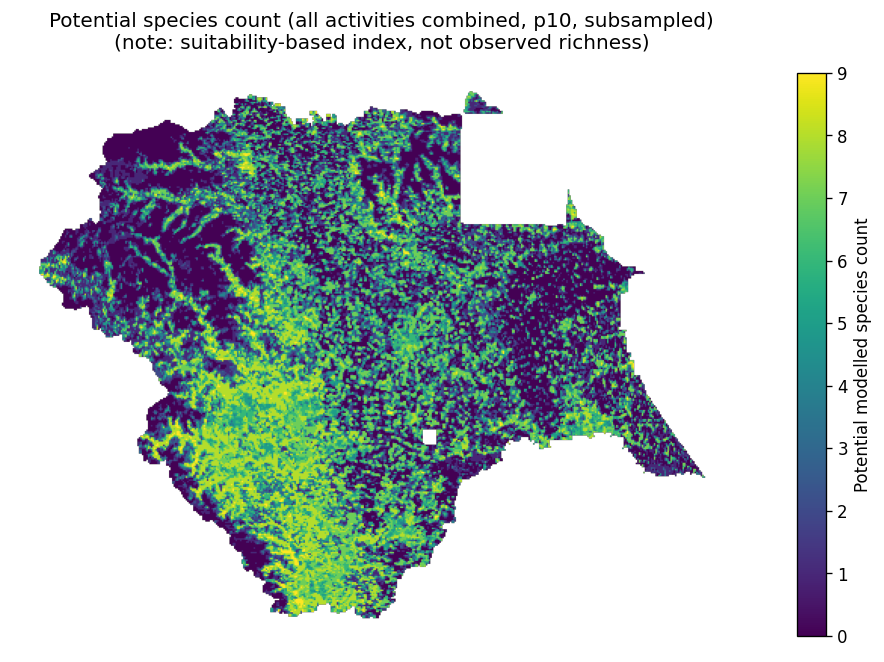

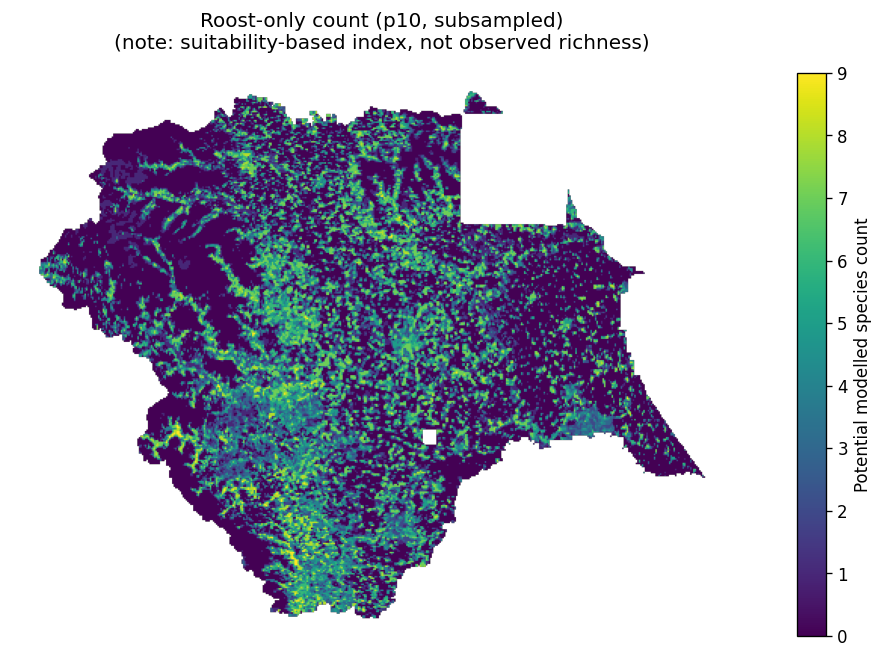

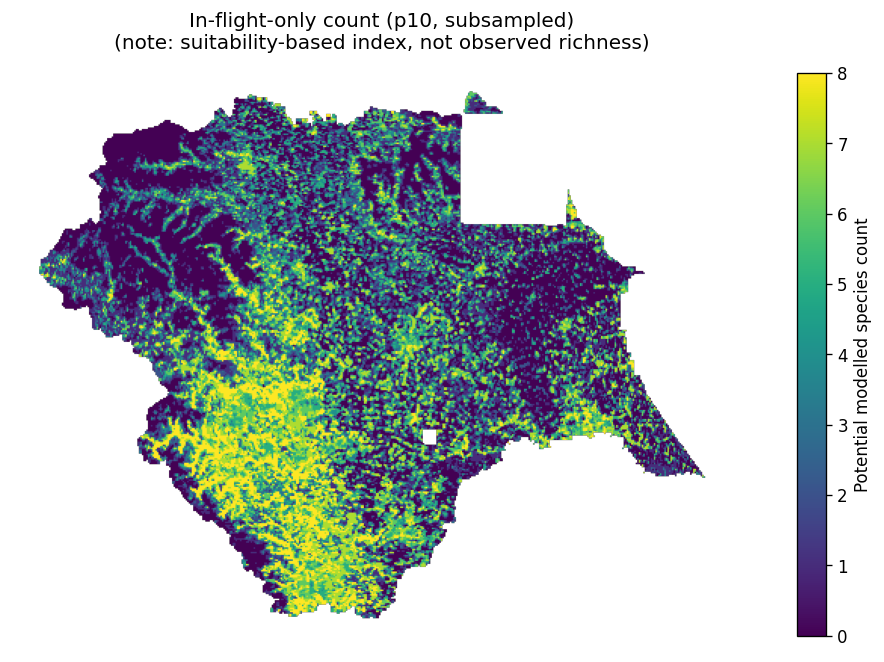

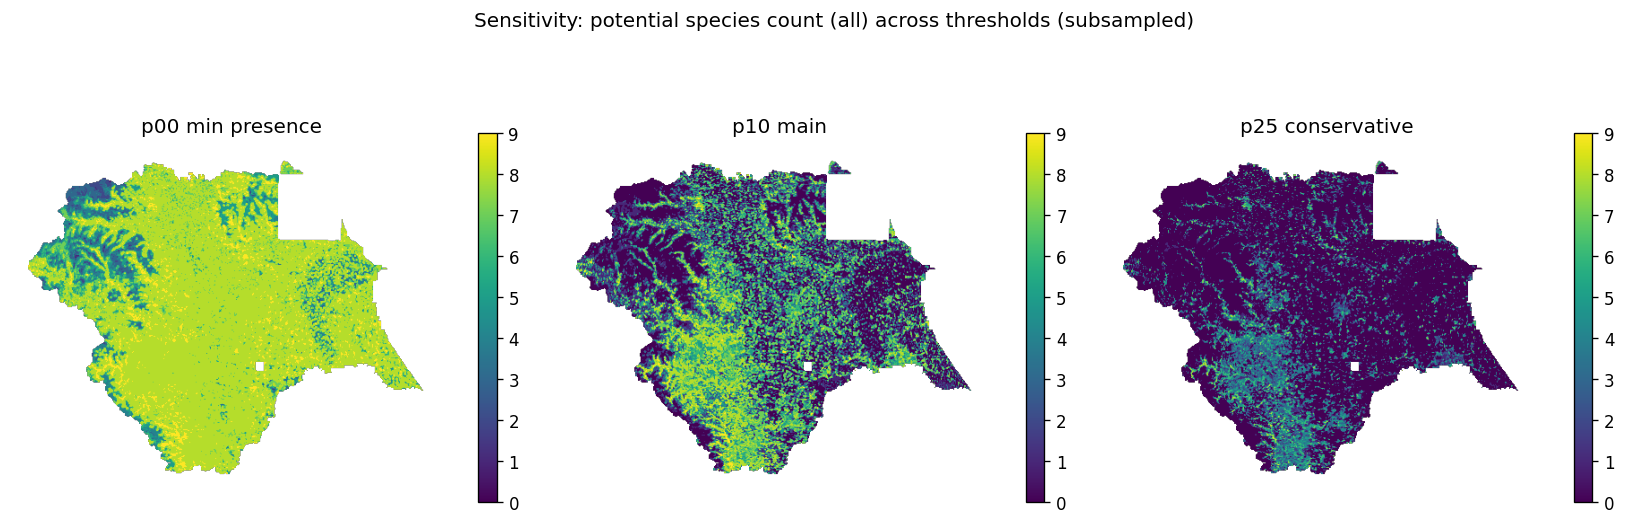

In [10]:
def plot_count_array(arr: np.ndarray, title: str) -> None:
    raw = np.asarray(arr, dtype=np.float64)
    a = np.ma.masked_where(~np.isfinite(raw), raw)
    finite = raw[np.isfinite(raw)]
    vmax = float(np.nanmax(finite)) if finite.size else 1.0
    vmax = max(1.0, vmax)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(
        orient_raster_plane_for_maps(a, transform=pred_info["transform"]),
        cmap="viridis",
        vmin=0.0,
        vmax=vmax,
        origin="upper",
    )
    plt.colorbar(im, ax=ax, shrink=0.7, label="Potential modelled species count")
    ax.set_title(
        title + chr(10) + "(note: suitability-based index, not observed richness)"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_count_array(
    aggregate_explore["p10_main"]["all"],
    "Potential species count (all activities combined, p10, subsampled)",
)
plot_count_array(
    aggregate_explore["p10_main"]["roost"],
    "Roost-only count (p10, subsampled)",
)
plot_count_array(
    aggregate_explore["p10_main"]["in_flight"],
    "In-flight-only count (p10, subsampled)",
)

# Sensitivity triptych
_triptych_labs = ["p00_min_presence", "p10_main", "p25_conservative"]
_triptych_arrs = []
for lab in _triptych_labs:
    raw = np.asarray(aggregate_explore[lab]["all"], dtype=np.float64)
    arr = np.ma.masked_where(~np.isfinite(raw), raw)
    _triptych_arrs.append(
        orient_raster_plane_for_maps(arr, transform=pred_info["transform"])
    )


def _finite_max(ma: np.ma.MaskedArray) -> float:
    vals = ma.compressed().astype(np.float64)
    return float(vals.max(initial=1.0)) if vals.size else 1.0


_triptych_vmax = max(1.0, max(_finite_max(x) for x in _triptych_arrs))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, arr, ttl in zip(
    axes, _triptych_arrs, ["p00 min presence", "p10 main", "p25 conservative"]
):
    im = ax.imshow(
        arr,
        cmap="viridis",
        vmin=0.0,
        vmax=_triptych_vmax,
        origin="upper",
    )
    ax.set_title(ttl)
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle(
    "Sensitivity: potential species count (all) across thresholds (subsampled)"
)
plt.tight_layout()
plt.show()


## 9. Optional: contributions at one high-count pixel


In [11]:
# Pick a high-count pixel on the subsampled p10 "all" layer, then sample full-resolution EV stack at mapped location

z = aggregate_explore["p10_main"]["all"]
vm = np.isfinite(z) & (z > 0)
if vm.any():
    flat = np.argmax(z * vm)
    r, c = np.unravel_index(flat, z.shape)
    H, W = pred_info["shape"]
    hs, ws = EXPLORE_GRID_SHAPE
    r_full = min(int((r + 0.5) * H / hs), H - 1)
    c_full = min(int((c + 0.5) * W / ws), W - 1)
    win = Window(c_full, r_full, 1, 1)
    print(
        f"Subsampling grid (row, col)=({r}, {c}); approx full-res centred near (row,col)=({r_full}, {c_full})"
    )

    with rio.open(PATH_PREDICTIONS) as srcp:
        contig = np.array(
            [
                srcp.read(i + 1, window=win)[0, 0]
                for i in range(len(pred_info["descriptions"]))
            ]
        )
    rows_demo = []
    for bk in raster_band_keys_ordered:
        ib = pred_info["descriptions"].index(bk)
        score = float(contig[ib])
        tr = th_lookup.loc[bk]
        thr = float(tr["threshold_p10_main"])
        rows_demo.append(
            {
                "Location": f"rc_full_{r_full}_{c_full}",
                "Species": tr["latin_name"],
                "Activity": tr["activity_type"],
                "Continuous score": score,
                "Threshold (p10)": thr,
                "Suitable?": score >= thr,
            }
        )
    display(pd.DataFrame(rows_demo))
else:
    print("No suitable pixels on subsampled aggregate — skip drill-down.")


Subsampling grid (row, col)=(0, 0); approx full-res centred near (row,col)=(2, 2)


,Location,Species,Activity,Continuous score,Threshold (p10),Suitable?
0,rc_full_2_2,Nyctalus noctula,In flight,-9999.0,0.211836,False
1,rc_full_2_2,Nyctalus noctula,Roost,-9999.0,0.252342,False
2,rc_full_2_2,Pipistrellus pipistrellus,In flight,-9999.0,0.264156,False
3,rc_full_2_2,Pipistrellus pipistrellus,Roost,-9999.0,0.177505,False
4,rc_full_2_2,Pipistrellus pygmaeus,In flight,-9999.0,0.155125,False
5,rc_full_2_2,Pipistrellus pygmaeus,Roost,-9999.0,0.165774,False
6,rc_full_2_2,Myotis daubentonii,In flight,-9999.0,0.102357,False
7,rc_full_2_2,Myotis daubentonii,Roost,-9999.0,0.089460,False
8,rc_full_2_2,Plecotus auritus,In flight,-9999.0,0.191168,False
9,rc_full_2_2,Plecotus auritus,Roost,-9999.0,0.109772,False


## 10. Conclusions (edit after run)

- **Alignment:** confirm whether `band_key` matched all intended models; review any warnings from §2.
- **Threshold choice:** inspect `threshold_summary` / `qa_df` in-session; omission rates vs `suitable_area_percent` (on subsampled grids); p10 is a convention, not biology.
- **Problematic models:** rows with `warning` / low `n_presence` / low CV.
- **Sensitivity:** compare the three panels in §8 (`aggregate_explore` across thresholds).
- **Next steps for production:** outputs are **`aggregate_*`** (nine COGs), **`threshold_binary_*`** (3 × *n* matched bands), **`aggregate_qa_latest.csv`** under **`data/sdm_predictions/`** (**EPSG:3857**, overwritten each run); pin versions externally if CI/publication requires it.

**Caveats**

- Maps and binary stats here use **`PLOT_STEP` subsampling** — not identical to native-resolution production outputs.
- Maps show *potential* modelled suitability, not confirmed bats.
- Aggregate counts are model-derived; do not report as field-observed richness.

### Code organisation notes

- **`band_axes`**: single table for raster-band order (`latin_name`, `activity_type`, `band_ix`) — avoids rebuilding dict/index maps in every section.
- **`xarray`**: named dimensions `("band_key", "y", "x")` for subsampled grids; slicing by activity/roost reduces index bookkeeping.
- Helpers keep loops minimal: vectorised masking for binary layers, pandas `explode`/merge paths for QA, small pure functions grouped before §3.
